### Chapter 10: Model Explainability using SHAP

## Objective

High predictive accuracy alone is insufficient for deploying machine learning models in regulated financial environments.

Financial institutions require transparent and interpretable models that allow analysts, auditors, and stakeholders to understand the factors influencing each prediction.

This notebook applies SHAP (SHapley Additive exPlanations) to interpret the final tuned LightGBM model.

The explainability analysis includes:

- Global feature importance
- Local feature contributions
- Feature interaction analysis
- Individual borrower explanations
- Business interpretation of prediction drivers

This chapter improves model transparency and supports explainable credit risk assessment within the broader IFRS 9 framework.

In [4]:
# ============================================================
# Chapter 10 : SHAP Explainability
# ============================================================

import joblib
import shap

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path
PROJECT_ROOT = Path.cwd().parent      # if notebook is inside notebooks/
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(exist_ok=True)

shap.initjs()
#It loads the JavaScript required for interactive SHAP visualizations, such as the Force Plot, in Jupyter notebooks.

In [5]:
# loading the final model - we will use LightGBM

lgbm_model = joblib.load(
    MODEL_DIR / "final_lgbm_model.pkl"
)

In [6]:
# Load Test Dataset

X_test = pd.read_csv(
    DATA_DIR / "processed/base_X_test.csv"
)

y_test = pd.read_csv(
    DATA_DIR / "processed/base_y_test.csv"
).squeeze()

print(X_test.shape)
print(y_test.shape)

(10243, 56)
(10243,)


**1. Create SHAP Explainer**

In [7]:
explainer = shap.TreeExplainer(lgbm_model)

print(type(explainer))

<class 'shap.explainers._tree.TreeExplainer'>


In [8]:
shap_values = explainer(X_test)

# Computing SHAP Values

After creating the SHAP explainer, the next step is to compute SHAP values for the test dataset.

SHAP values quantify the contribution of each feature to every individual prediction.

For every borrower, SHAP decomposes the model prediction into:

- A baseline prediction (expected value)
- Positive feature contributions that increase the predicted risk
- Negative feature contributions that decrease the predicted risk

These explanations form the foundation for all subsequent visualizations and interpretations.

In [10]:
print(type(shap_values))
print(shap_values.shape)

<class 'shap._explanation.Explanation'>
(10243, 56, 4)


**Why three dimensions?**

- Your model predicts 4 classes:

`P1, P2, P3, P4`

For every borrower

↓

For every feature

↓

SHAP computes a contribution for each class.

So the dimensions become

(number of borrowers,
 number of features,
 number of classes)

In [13]:
# let us inspect One Borrower
print(shap_values[0].shape) # each borrower has 56 features and it is divided into 4 classes(The Contribution)
shap_values[0]

(56, 4)


.values =
array([[ 4.17299441e-02,  1.64081731e-02, -5.21901518e-03,
        -2.36503053e-03],
       [-9.04350425e-04, -3.12264798e-02,  9.76829065e-03,
        -7.44615344e-03],
       [-8.13685136e-03,  3.93258785e-02, -7.69756468e-03,
        -1.90842307e-02],
       [ 9.51151344e-02,  3.08610608e-02,  1.56511386e-02,
        -1.08984592e-01],
       [-1.24022542e-02,  7.38222833e-02,  6.67376227e-03,
        -1.02606824e-02],
       [ 5.02857618e-03, -8.96833683e-04,  3.74476100e-03,
        -2.61034687e-02],
       [-2.76513583e-04, -2.92644763e-04, -1.32157099e-03,
         2.82244856e-03],
       [-7.51812436e-03, -4.14756225e-04,  4.99717916e-04,
         7.24583376e-03],
       [ 9.70439032e-04,  2.30632612e-02, -1.03339848e-02,
        -9.54010470e-04],
       [ 1.69534942e-02, -4.69929299e-02,  3.28807814e-03,
         2.78519625e-03],
       [ 1.64266157e-02,  1.58036261e-02, -3.05773723e-03,
        -1.57597651e-02],
       [ 1.22202954e-02,  1.09217466e-01,  3.35159871e-

In [15]:
print("Values shape :", shap_values.values.shape)
print("Base values shape :", shap_values.base_values.shape)
print("Data shape :", shap_values.data.shape)
print("Features :", len(shap_values.feature_names))

Values shape : (10243, 56, 4)
Base values shape : (10243, 4)
Data shape : (10243, 56)
Features : 56


### 2. Global Feature Importance

Global feature importance summarizes how much each feature contributes to the model's predictions across the entire dataset.

- Unlike traditional feature importance measures that rely on tree structure or split frequency, SHAP computes the average absolute contribution of each feature to the model output.

- Features with larger mean absolute SHAP values have a greater overall influence on the predicted credit risk ratings.

`This analysis helps identify the primary drivers of credit risk within the trained model.`

There are TWO ways to explain the feature importance 
- Feature Importance class-wise
- Global ranking across all classes

In [16]:
# ============================================================
# Global SHAP Feature Importance
# ============================================================

# Average absolute SHAP values
global_importance = np.abs(shap_values.values).mean(axis=(0, 2))

shap_importance = (
    pd.DataFrame({
        "Feature": X_test.columns,
        "Mean |SHAP|": global_importance
    })
    .sort_values("Mean |SHAP|", ascending=False)
    .reset_index(drop=True)
)

display(shap_importance.head(20))

,Feature,Mean |SHAP|
0,enq_L3m,0.711308
1,Age_Oldest_TL,0.654858
2,max_recent_level_of_deliq,0.536134
3,num_std_12mts,0.346062
4,pct_PL_enq_L6m_of_ever,0.230387
5,time_since_recent_enq,0.152934
6,Age_Newest_TL,0.107324
7,recent_level_of_deliq,0.071860
8,max_deliq_12mts,0.071856
9,pct_tl_open_L12M,0.060208


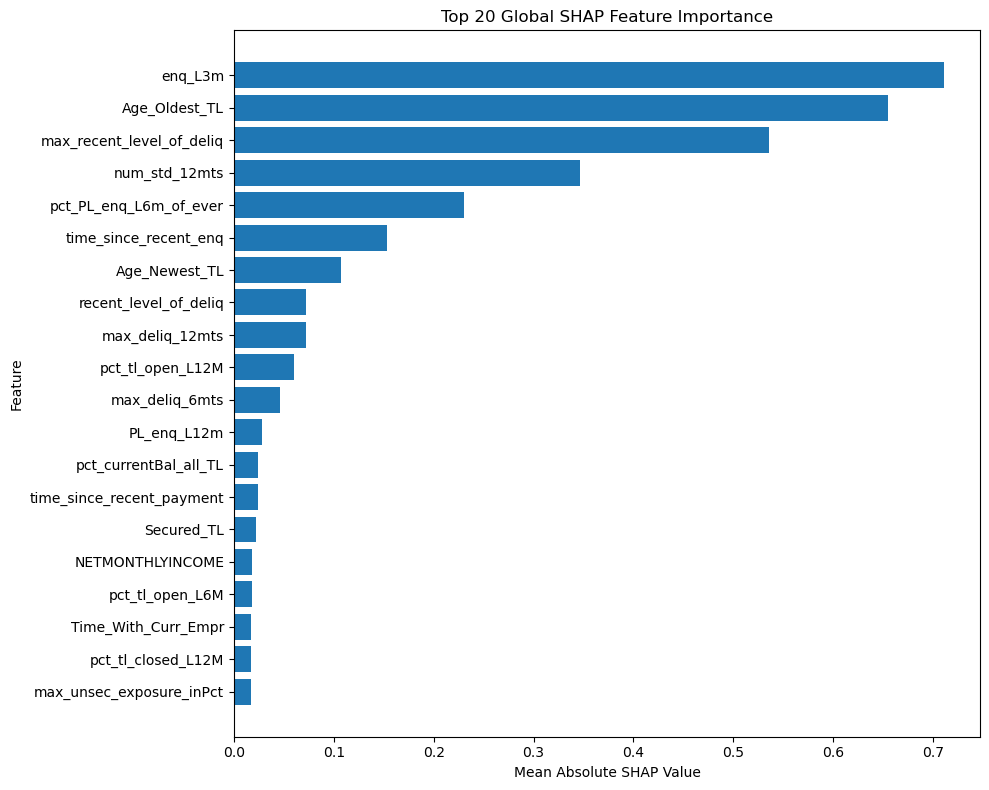

In [17]:
# ============================================================
# Top 20 Global Features
# ============================================================

plt.figure(figsize=(10, 8))

plt.barh(
    shap_importance["Feature"][:20][::-1],
    shap_importance["Mean |SHAP|"][:20][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 20 Global SHAP Feature Importance")

plt.tight_layout()
plt.show()

- Notice something interesting.

Our top features are not demographic.

They are primarily related to:

- Credit enquiries
- Delinquencies
- Trade line history
- Credit behavior

**Business interpretation**

- Frequent recent credit enquiries often indicate that a borrower is actively seeking additional credit.

This behavior can be associated with:

- Increased financial stress
- Higher borrowing demand
- Greater default risk

Therefore, it is reasonable that the model relies heavily on this feature.

"The SHAP analysis showed that the model primarily relies on behavioral credit features rather than demographic information. Recent credit enquiries, delinquency history, and trade line age were the strongest drivers of credit risk predictions. This aligns well with established credit risk practices, where repayment behavior and credit activity are generally more predictive of default than static borrower characteristics such as income."

### ***SHAP Beeswarm Plot***
While the global feature importance plot ranks features by their average contribution, it does not indicate whether high or low feature values increase or decrease the predicted credit risk.

The SHAP beeswarm plot provides a more comprehensive view by displaying:

- Overall feature importance
- Direction of feature influence
- Distribution of SHAP values
- Variation in feature effects across borrowers

Each point represents one borrower.

The horizontal position indicates the impact of a feature on the model prediction, while the color represents the corresponding feature value.
Since BeeSwarm can be used to get the SHAP values for individual classes, we will go for P4(since this is the riskiest class)

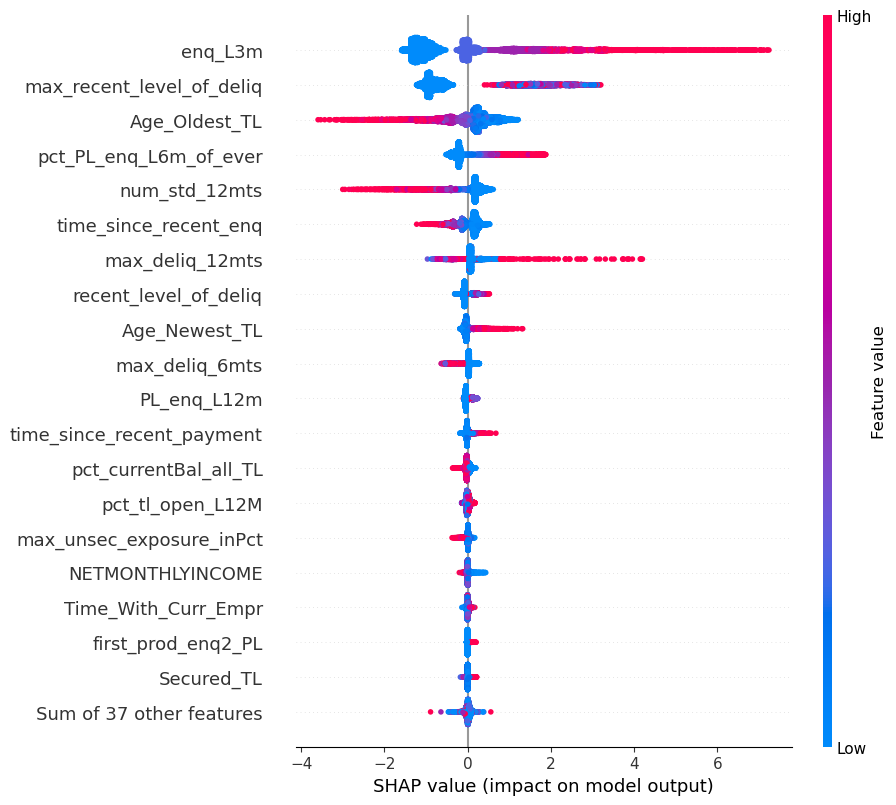

In [18]:
# ============================================================
# SHAP Beeswarm Plot (P4)
# ============================================================

P4_INDEX = 3

shap.plots.beeswarm(
    shap.Explanation(
        values=shap_values.values[:, :, P4_INDEX],
        base_values=shap_values.base_values[:, P4_INDEX],
        data=shap_values.data,
        feature_names=shap_values.feature_names
    ),
    max_display=20
)

### ***Feature-by-Feature Interpretation***
**1. enq_L3m (Recent Enquiries)** 

This is the strongest feature.

What do we see?
- Red points (high enquiries) are concentrated on the right.
- Blue points (few enquiries) are concentrated on the left.

**Interpretation**

- Borrowers with many recent credit enquiries are much more likely to be classified as P4.

- Borrowers with very few enquiries are pushed towards lower-risk grades.

**Business Interpretation**

- Frequent credit enquiries often indicate aggressive borrowing behaviour or financial stress. Consequently, the model treats recent enquiry activity as the strongest indicator of elevated credit risk.

### Interpretation of the SHAP Beeswarm Plot

The SHAP beeswarm plot provides both the magnitude and direction of each feature's contribution toward the prediction of the highest credit risk class (P4).

The analysis indicates that behavioural credit features dominate the model's decision-making process. Recent credit enquiries (`enq_L3m`) emerge as the strongest predictor, with higher enquiry counts consistently increasing the likelihood of a borrower being classified into the highest risk grade. Similarly, recent delinquency measures (`max_recent_level_of_deliq`, `recent_level_of_deliq`, and `max_deliq_12mts`) contribute positively toward higher predicted credit risk.

Conversely, longer credit history (`Age_Oldest_TL`) and a greater number of standard-performing accounts (`num_std_12mts`) generally reduce the predicted risk, reflecting the model's preference for borrowers with established and stable repayment behaviour.

Overall, the SHAP analysis demonstrates that the model primarily relies on dynamic behavioural credit indicators rather than demographic attributes, which is consistent with established credit risk assessment practices and enhances confidence in the model's practical applicability.

### ***SHAP Dependence Plots***

Global feature importance identifies which variables influence the model most strongly, but it does not reveal how changes in feature values affect the prediction.

SHAP dependence plots visualize the relationship between an individual feature and its SHAP value across all borrowers.

Each point represents one borrower.

These plots help identify:

- Positive or negative relationships
- Nonlinear behaviour
- Threshold effects
- Potential feature interactions

Understanding these relationships is particularly valuable in credit risk modelling, where financial variables often exhibit complex, non-linear effects.

In [19]:
# features we are intersted in looking:
top_features = [
    "enq_L3m",
    "Age_Oldest_TL",
    "max_recent_level_of_deliq",
    "num_std_12mts",
    "time_since_recent_enq"
]

**Creating a Class-Specific SHAP Object**

We'll reuse the P4 explanation:

In [20]:
# ============================================================
# SHAP Explanation for P4
# ============================================================

P4_INDEX = 3

shap_p4 = shap.Explanation(
    values=shap_values.values[:, :, P4_INDEX],
    base_values=shap_values.base_values[:, P4_INDEX],
    data=shap_values.data,
    feature_names=shap_values.feature_names
)

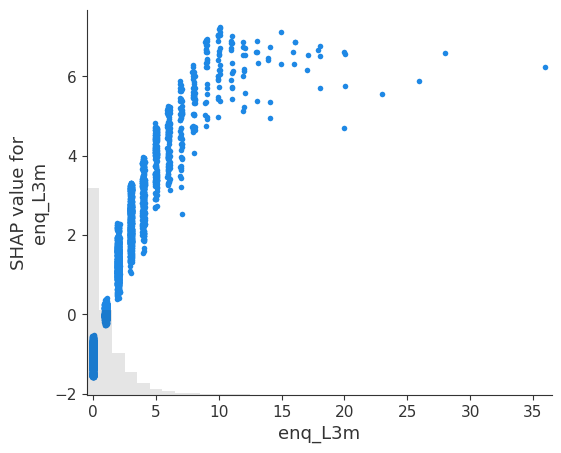

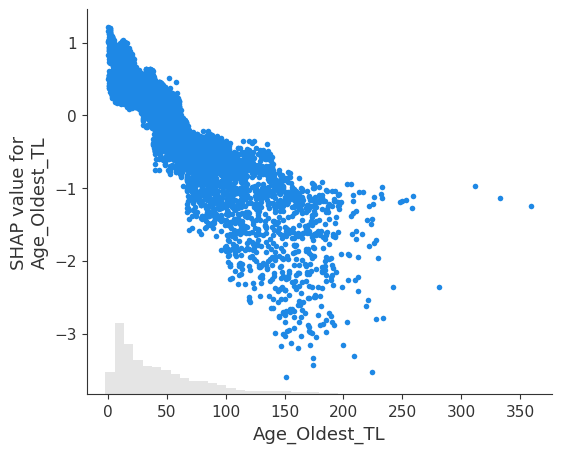

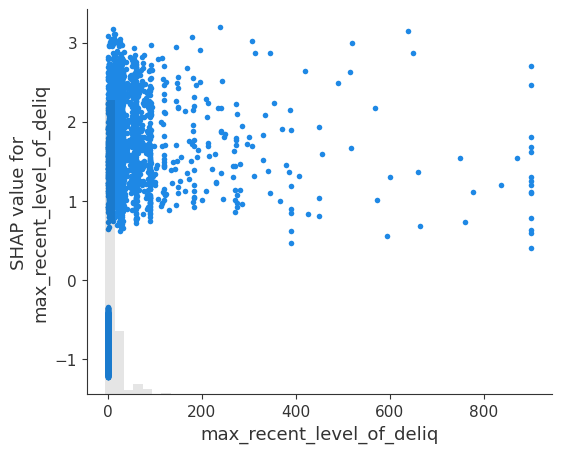

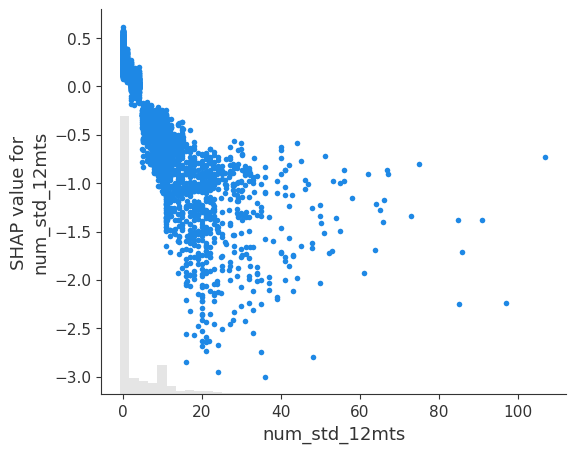

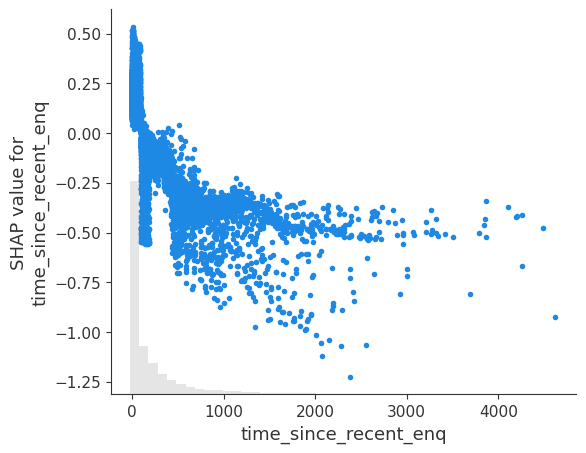

In [25]:
# Plot 1 For Number of enquiries in last 3 months
for feat in top_features:
    shap.plots.scatter(
        shap_p4[:, feat]
    )

### Interpretation of SHAP Dependence Plots

The SHAP dependence plots are consistent with the patterns observed in the SHAP beeswarm plot, providing feature-level insight into how individual variables influence the predicted probability of the highest credit risk class (P4).

Key observations include:

1. **Time Since Recent Enquiry (`time_since_recent_enq`)**
   - As the time since the most recent credit enquiry increases, the SHAP values become increasingly negative.
   - This indicates that borrowers who have not sought new credit for a longer period are less likely to be classified into the highest risk category.
   - Conversely, very recent enquiries contribute positively towards higher predicted credit risk.

2. **Age of Oldest Trade Line (`Age_Oldest_TL`)**
   - Borrowers with older trade lines generally exhibit negative SHAP values.
   - This suggests that a longer credit history reduces the predicted credit risk, reflecting greater financial stability and repayment experience.

3. **Recent Credit Enquiries (`enq_L3m`)**
   - Higher numbers of recent credit enquiries produce increasingly positive SHAP values.
   - This demonstrates that frequent recent borrowing activity is one of the strongest contributors towards higher predicted credit risk.

Overall, these observations are consistent with established credit risk principles and reinforce that the model has learned meaningful behavioural patterns rather than relying primarily on demographic characteristics.

The dependence plots also reveal that many relationships are **non-linear**. Instead of changing proportionally with feature values, the SHAP contributions often exhibit threshold effects and varying rates of change. This indicates that the gradient boosting model captures complex decision boundaries and feature interactions, enabling it to model borrower behaviour more effectively than linear models.

***"The dependence plots validated that the model learned financially meaningful relationships. For example, more recent credit enquiries increased the contribution toward the highest-risk class, while a longer credit history reduced it. The plots also showed that these effects are non-linear, indicating that the gradient boosting model captures threshold effects and complex borrower behaviour that would not be represented by a linear model."***

# Local Explanation using SHAP Waterfall Plot


### Waterfall Plot
- This plots tells us the story behind a single borrower prediction i.e it goes locally and explains why model predicted the class it predicted for this borrower.

While global SHAP visualizations explain overall model behaviour, they do not explain individual predictions.

The SHAP Waterfall Plot decomposes a single prediction into the contributions of each feature.

Starting from the model's expected prediction (base value), each feature either increases or decreases the prediction until the final model output is reached.

This visualization provides a transparent explanation of why a particular borrower received a specific credit risk rating.

In [26]:
borrower_idx = 0 # we pick the borrower

In [27]:
# this code shows the 
P4_INDEX = 3

borrower_explanation = shap.Explanation(
    values=shap_values.values[borrower_idx, :, P4_INDEX],
    base_values=shap_values.base_values[borrower_idx, P4_INDEX],
    data=shap_values.data[borrower_idx],
    feature_names=shap_values.feature_names
)

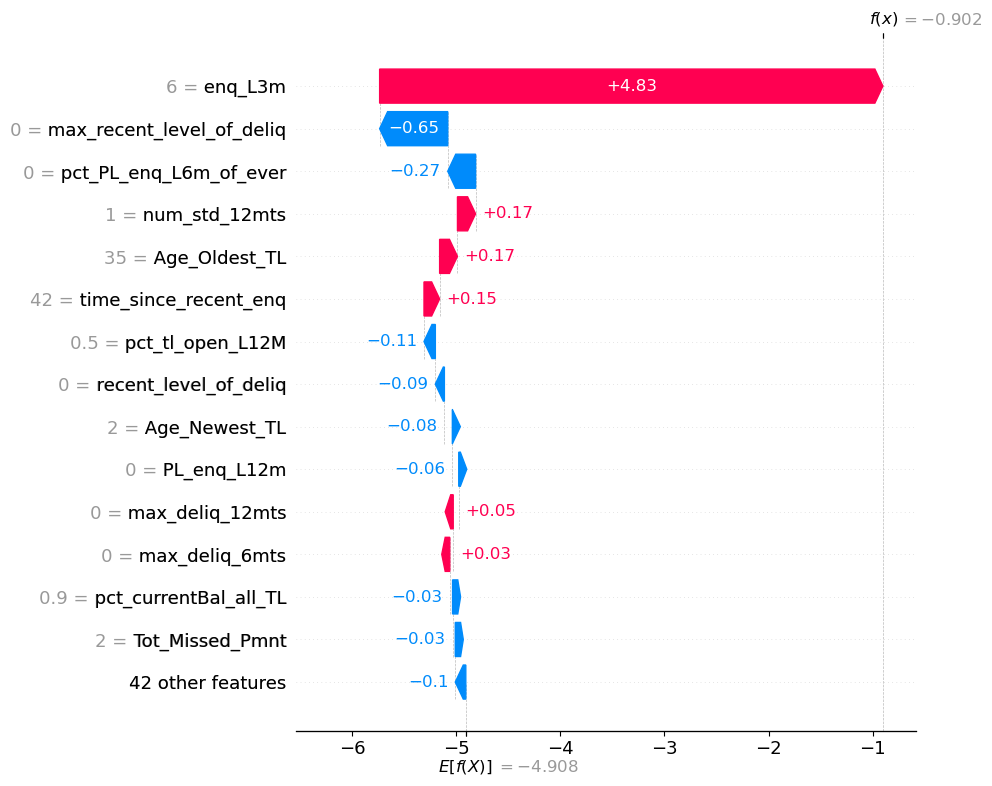

In [28]:
shap.plots.waterfall(
    borrower_explanation,
    max_display=15
)

Average Borrower
        │
        ▼
Low P4 Score

+ Very High Recent Enquiries (+4.83)
+ Few Standard Accounts
+ Other Minor Risk Factors

− No Recent Delinquency
− No Personal Loan Enquiries
− Other Protective Factors

────────────────────────────

Final P4 Score = -0.902

### Interpretation of the SHAP Waterfall Plot

The SHAP waterfall plot explains the prediction for an individual borrower by decomposing the model output into contributions from each feature.

The prediction begins at the model's baseline output and is adjusted according to the borrower's feature values until the final prediction is obtained.

For this borrower, the dominant factor increasing the predicted probability of the highest risk class (P4) is the exceptionally high number of recent credit enquiries (`enq_L3m = 6`), which contributes the largest positive SHAP value. This indicates that recent borrowing activity strongly influenced the model toward a higher risk assessment.

Several features partially offset this risk. The absence of recent delinquency (`max_recent_level_of_deliq = 0`) and the lack of recent personal loan enquiries reduce the predicted risk, demonstrating that the borrower also possesses favourable credit characteristics.

Overall, the prediction results from the combined influence of multiple behavioural credit variables rather than a single feature. The waterfall plot provides a transparent explanation of the model's reasoning for this individual borrower.

### ***Explaining a Misclassified Borrower***

While SHAP explanations are commonly used to interpret correct predictions, they are equally valuable for understanding model errors.

This section analyzes a misclassified borrower by examining the feature contributions that led the model to predict an incorrect credit risk class.

Such analysis helps identify:

- Which features dominated the model's reasoning.
- Whether the prediction was reasonable despite being incorrect.
- Potential overlap between neighbouring risk grades.
- Areas where additional features or data may improve model performance.

Understanding model failures is an essential component of responsible and explainable machine learning.

In [30]:
# ============================================================
# Generate Predictions
# ============================================================

lgbm_pred = lgbm_model.predict(X_test)
lgbm_proba = lgbm_model.predict_proba(X_test)

print("Prediction Shape :", lgbm_pred.shape)
print("Probability Shape :", lgbm_proba.shape)

Prediction Shape : (10243,)
Probability Shape : (10243, 4)


In [31]:
# ============================================================
# Find Misclassified Borrowers
# ============================================================

misclassified_idx = np.where(
    lgbm_pred != y_test
)[0]

print(f"Total Misclassified Borrowers: {len(misclassified_idx)}")

Total Misclassified Borrowers: 2098


In [35]:
# ============================================================
# Highest-Confidence Misclassified Borrower
# ============================================================
lgbm_confidence = np.max(lgbm_proba, axis=1)
highest_conf_error_idx = misclassified_idx[
    np.argmax(lgbm_confidence[misclassified_idx])
]

print("="*60)
print("Highest Confidence Misclassified Borrower")
print("="*60)

print(f"Borrower Index       : {highest_conf_error_idx}")
print(f"Actual Class         : {class_names[y_test.iloc[highest_conf_error_idx]]}")
print(f"Predicted Class      : {class_names[lgbm_pred[highest_conf_error_idx]]}")
print(f"Prediction Confidence: {lgbm_confidence[highest_conf_error_idx]:.2%}")

Highest Confidence Misclassified Borrower
Borrower Index       : 6519
Actual Class         : P3
Predicted Class      : P4
Prediction Confidence: 99.25%


- This index data was misclassified with highest confidence

### Create SHAP Explanation

In [36]:
predicted_class = lgbm_pred[highest_conf_error_idx]

misclassified_explanation = shap.Explanation(
    values=shap_values.values[
        highest_conf_error_idx,
        :,
        predicted_class
    ],
    base_values=shap_values.base_values[
        highest_conf_error_idx,
        predicted_class
    ],
    data=shap_values.data[
        highest_conf_error_idx
    ],
    feature_names=shap_values.feature_names
)

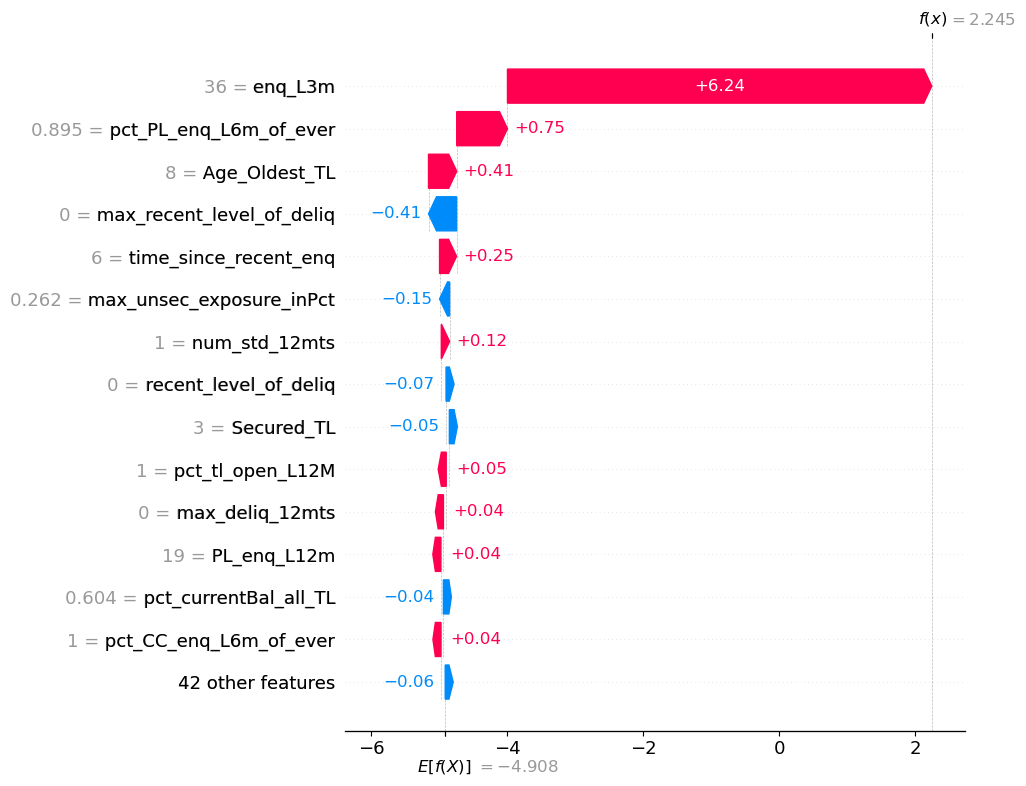

In [37]:
shap.plots.waterfall(
    misclassified_explanation,
    max_display=15
)

WHY WAS THIS MISCLASSIFIED??
- obviously the data had 36 enquiries in last 3 months, it had to be in highest risk class P4, but actually the borrower was in P3.
But since our model learned that Feature `enq_L3m` is heavily positively correlated with risk, that is why our model predicted this borrower with `99.25%` confidence.

Contribution of `enq_L3m`:
+6.24

That's enormous.

Remember our global SHAP analysis:

enq_L3m was the #1 feature.
The dependence plot showed that higher enquiry counts strongly increase the P4 score.
The waterfall plot now shows exactly the same behavior for this individual.

This means the model is being internally consistent.

In [38]:
# ============================================================
# Feature Values of the Misclassified Borrower
# ============================================================

borrower_features = X_test.iloc[
    highest_conf_error_idx
].to_frame(name="Value")

display(borrower_features)

,Value
pct_tl_open_L6M,0.833
pct_tl_closed_L6M,0.333
Tot_TL_closed_L12M,2.000
pct_tl_open_L12M,1.000
pct_tl_closed_L12M,0.333
Tot_Missed_Pmnt,1.000
CC_TL,0.000
Home_TL,0.000
PL_TL,1.000
Secured_TL,3.000


### Interpretation of a High-Confidence Misclassification

This borrower represents one of the model's highest-confidence misclassifications. Although the true label belongs to a lower risk grade, the model predicts the highest risk class (P4) with high confidence.

The SHAP explanation reveals that this prediction is driven primarily by an exceptionally large number of recent credit enquiries (`enq_L3m = 36`), which contributes overwhelmingly toward the P4 prediction. Additional behavioural indicators, including a high proportion of recent personal loan enquiries and a relatively short credit history, further increase the predicted risk.

While the borrower exhibits favourable characteristics such as the absence of recent delinquency, these factors are insufficient to offset the exceptionally strong risk signal generated by the enquiry-related variables.

This example illustrates that the model's prediction is internally consistent with the learned relationships identified during the global SHAP analysis. Rather than indicating arbitrary model behaviour, the explanation suggests that the borrower possesses behavioural characteristics strongly associated with the highest risk class. The discrepancy between the predicted and actual labels may therefore reflect overlap between adjacent risk grades, limitations of the available features, or potential uncertainty in the ground-truth labels.

==========================================================================================================================================
# Overall Explainability Summary

## Objective

The objective of this chapter was to improve the transparency of the final LightGBM credit risk model by explaining both its global decision-making behaviour and individual borrower predictions using SHAP (SHapley Additive Explanations).

Unlike conventional feature importance measures, SHAP provides consistent feature attributions for every prediction, making the model interpretable at both the portfolio and borrower levels.

---

## Key Findings

### Global Feature Importance

The global SHAP analysis identified behavioural credit variables as the primary drivers of the model's predictions.

The most influential features include:

- Recent credit enquiries (`enq_L3m`)
- Age of the oldest trade line (`Age_Oldest_TL`)
- Recent delinquency severity (`max_recent_level_of_deliq`)
- Number of standard accounts (`num_std_12mts`)
- Personal loan enquiry behaviour

These features are consistent with established credit risk assessment principles, where borrower behaviour generally provides stronger predictive power than demographic information.

---

### Feature Behaviour

The SHAP beeswarm and dependence plots demonstrated that the model learned meaningful, non-linear relationships between borrower characteristics and predicted credit risk.

Key observations include:

- A larger number of recent credit enquiries consistently increases the likelihood of the highest risk class.
- Longer credit histories generally reduce predicted credit risk.
- Recent delinquency contributes positively towards higher predicted risk.
- Stable repayment behaviour reduces the model's estimated credit risk.

These findings indicate that the model captures realistic behavioural patterns rather than relying on simplistic linear relationships.

---

### Local Explanations

Waterfall plots were used to explain individual borrower predictions.

For each borrower, the model prediction was decomposed into feature-level contributions, illustrating how behavioural characteristics collectively increased or decreased the predicted credit risk.

This level of transparency enables analysts to understand the reasoning behind individual predictions rather than treating the model as a black box.

---

### Explaining Model Errors

SHAP explanations were also applied to one of the model's highest-confidence misclassifications.

The analysis revealed that the prediction was primarily driven by an exceptionally large number of recent credit enquiries, together with several additional behavioural indicators associated with higher credit risk.

Although the predicted class differed from the dataset label, the feature contributions demonstrated that the model's reasoning remained internally consistent with the global behavioural patterns learned during training.

This highlights the value of explainable AI for model validation, allowing prediction errors to be investigated rather than simply reported.

---

## Overall Assessment

The SHAP analysis confirms that the final LightGBM model makes decisions based on financially meaningful behavioural credit variables and exhibits consistent decision logic across both global and individual explanations.

The model demonstrates a high degree of transparency, enabling users to understand why a borrower receives a particular internal credit risk rating.

Such explainability is particularly valuable in regulated financial environments, where model transparency, auditability, and interpretability are essential components of responsible credit risk modelling.

---

## Transition to IFRS 9

Having established that the selected model is both accurate and explainable, the next phase of the project shifts from predictive modelling to business implementation.

The subsequent chapter will transform the model outputs into an IFRS 9-compliant Expected Credit Loss (ECL) framework by integrating:

- Internal Risk Rating → Probability of Default (PD) Mapping
- Loss Given Default (LGD)
- Exposure at Default (EAD)
- Expected Credit Loss (ECL) Calculation
- Stage 1, Stage 2, and Stage 3 Classification
- Stress Testing and Portfolio-Level Risk Analysis

This transition marks the evolution of the project from a machine learning classification model into a comprehensive credit risk analytics and IFRS 9 decision-support system.